# Notebook 09 — Evaluation, Postprocessing & Visualization

> **No training required** — loads `best_model.pth` and runs inference only.

---

## Objectives

- Load the trained SegResNet checkpoint
- Compute per-subregion Dice: **WT / TC / ET** (not just mean)
- Apply **Largest Connected Component** postprocessing
- Compare Dice before vs after postprocessing
- Visualize predictions on validation patients

## BraTS Subregion Definitions

| Subregion | Labels included | Clinical meaning |
|-----------|----------------|-----------------|
| **WT** — Whole Tumor | 1 + 2 + 3 | Full tumor extent |
| **TC** — Tumor Core | 1 + 3 | Necrotic core + enhancing |
| **ET** — Enhancing Tumor | 3 | Active tumor (hardest to segment) |

## 1. Setup

### 1.1 Install Dependencies

In [1]:
!pip -q install monai scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.0 MB/s eta 0:00:00


### 1.2 Imports

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import SegResNet
from monai.inferers import SlidingWindowInferer
from monai.transforms import (
    Compose,
    Activations,
    AsDiscrete,
)
from monai.metrics import DiceMetric

from scipy import ndimage

2026-06-28 12:24:40.479225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782649480.675745      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782649480.733713      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782649481.180513      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782649481.180566      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782649481.180570      16 computation_placer.cc:177] computation placer alr

### 1.3 Paths & Constants

In [3]:
PROCESSED_PATH = Path(
    "/kaggle/input/datasets/mariammohamed1095/workingg/datasets/processed/cv"
)

CHECKPOINT_PATH = Path(
    "/kaggle/input/models/mariammohamed1095/brats2020-segresnet/pytorch/default/1/models/segmentation/best_model.pth"
)

FIGURE_DIR = Path("/kaggle/working/reports/figures")
RESULT_DIR = Path("/kaggle/working/reports/results")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

ROI_SIZE    = (128, 128, 128)
NUM_CLASSES = 4
SW_BATCH_SIZE = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Checkpoint:", CHECKPOINT_PATH)

Device: cpu
Checkpoint: /kaggle/input/models/mariammohamed1095/brats2020-segresnet/pytorch/default/1/models/segmentation/best_model.pth


## 2. Load Model

### 2.1 Build SegResNet

In [4]:
model = SegResNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    init_filters=32,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

print(model.__class__.__name__)

SegResNet


### 2.2 Load Checkpoint

In [5]:
state_dict = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

# best_model.pth contains only the state dict (saved via torch.save(model.state_dict(), ...))
# last_model.pth contains the full checkpoint dict — use ["model_state_dict"] for that one
model.load_state_dict(state_dict)
model.eval()

print("Checkpoint loaded successfully.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Checkpoint loaded successfully.
Parameters: 18,798,660


## 3. Validation Dataset

### 3.1 PreprocessedDataset

In [6]:
class PreprocessedDataset(Dataset):

    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.files    = sorted(self.root_dir.glob("*.pt"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = torch.load(self.files[index], weights_only=False)
        return {
            "image":      sample["image"],
            "label":      sample["label"],
            "metadata":   sample["metadata"],
            "patient_id": sample["patient_id"],
        }


val_dataset = PreprocessedDataset(PROCESSED_PATH / "validation")
print("Validation patients:", len(val_dataset))

Validation patients: 56


### 3.2 DataLoader

In [7]:
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

### 3.3 Inferer

In [8]:
inferer = SlidingWindowInferer(
    roi_size=ROI_SIZE,
    sw_batch_size=SW_BATCH_SIZE,
    overlap=0.5,
)

post_pred = Compose([
    Activations(softmax=True),
    AsDiscrete(argmax=True),
])

print("Inferer ready.")

Inferer ready.


## 4. Per-Subregion Dice

### 4.1 Subregion Helper Functions

BraTS subregions are derived from the raw class predictions:

| Subregion | How to compute |
|-----------|---------------|
| WT | `pred > 0` (any non-background label) |
| TC | `pred == 1` or `pred == 3` |
| ET | `pred == 3` |

In [9]:
def compute_dice(pred_bin, label_bin):
    """
    Compute binary Dice score between two boolean tensors.

    Parameters
    ----------
    pred_bin  : torch.Tensor  boolean, any shape
    label_bin : torch.Tensor  boolean, same shape

    Returns
    -------
    float — Dice score in [0, 1], or 1.0 if both are empty (true negative)
    """
    pred_bin  = pred_bin.bool()
    label_bin = label_bin.bool()

    intersection = (pred_bin & label_bin).sum().item()
    pred_sum     = pred_bin.sum().item()
    label_sum    = label_bin.sum().item()

    if pred_sum == 0 and label_sum == 0:
        return 1.0

    if pred_sum + label_sum == 0:
        return 0.0

    return (2.0 * intersection) / (pred_sum + label_sum)


def compute_subregion_dice(pred, label):
    """
    Compute WT / TC / ET Dice for a single patient.

    Parameters
    ----------
    pred  : torch.Tensor  shape (D, H, W), integer class indices [0,1,2,3]
    label : torch.Tensor  shape (1, D, H, W) or (D, H, W), integer class indices

    Returns
    -------
    dict with keys: wt, tc, et
    """
    label = label.squeeze()

    wt_pred  = pred > 0
    tc_pred  = (pred == 1) | (pred == 3)
    et_pred  = pred == 3

    wt_label = label > 0
    tc_label = (label == 1) | (label == 3)
    et_label = label == 3

    return {
        "wt": compute_dice(wt_pred,  wt_label),
        "tc": compute_dice(tc_pred,  tc_label),
        "et": compute_dice(et_pred,  et_label),
    }

## 5. Largest Connected Component Postprocessing

### 5.1 LCC Function

For each non-background class, keep only the largest connected component
and discard all smaller disconnected fragments (noise).

This is a standard postprocessing step for BraTS segmentation — small
disconnected predictions are almost always false positives.

In [10]:
def keep_largest_connected_component(pred_np):
    """
    Apply largest connected component filtering per class.

    Parameters
    ----------
    pred_np : np.ndarray  shape (D, H, W), integer class indices [0,1,2,3]

    Returns
    -------
    np.ndarray  same shape, with small disconnected components removed
    """
    result = np.zeros_like(pred_np)

    for class_idx in [1, 2, 3]:

        binary = (pred_np == class_idx)

        if binary.sum() == 0:
            continue

        labeled, num_features = ndimage.label(binary)

        if num_features == 0:
            continue

        # Find the largest component
        component_sizes = ndimage.sum(binary, labeled, range(1, num_features + 1))
        largest_label   = np.argmax(component_sizes) + 1

        result[labeled == largest_label] = class_idx

    return result

## 6. Full Evaluation Loop

Run inference on all 56 validation patients, compute per-subregion Dice
before and after LCC postprocessing.

In [11]:
records = []

with torch.no_grad():

    for i, batch in enumerate(val_loader):

        patient_id = batch["patient_id"][0]
        image      = batch["image"].to(device)   # (1, 4, D, H, W)
        label      = batch["label"]              # (1, 1, D, H, W)

        # Sliding window inference
        logits = inferer(image, model)           # (1, 4, D, H, W)

        # Raw prediction — class indices
        pred_raw = post_pred(logits[0]).squeeze()         # (D, H, W)

        # ── Before LCC ───────────────────────────────────────────────────────
        dice_before = compute_subregion_dice(pred_raw, label[0])

        # ── After LCC ────────────────────────────────────────────────────────
        pred_np  = pred_raw.cpu().numpy()
        pred_lcc = keep_largest_connected_component(pred_np)
        pred_lcc_tensor = torch.from_numpy(pred_lcc)

        dice_after = compute_subregion_dice(pred_lcc_tensor, label[0])

        records.append({
            "patient_id":  patient_id,
            "wt_before":   dice_before["wt"],
            "tc_before":   dice_before["tc"],
            "et_before":   dice_before["et"],
            "mean_before": np.mean([dice_before["wt"], dice_before["tc"], dice_before["et"]]),
            "wt_after":    dice_after["wt"],
            "tc_after":    dice_after["tc"],
            "et_after":    dice_after["et"],
            "mean_after":  np.mean([dice_after["wt"], dice_after["tc"], dice_after["et"]]),
            # store prediction for visualization
            "_pred_lcc":   pred_lcc,
            "_label":      label[0].squeeze().numpy(),
            "_image":      image[0].cpu().numpy(),
        })

        if (i + 1) % 10 == 0 or (i + 1) == len(val_loader):
            print(f"  [{i+1:02d}/{len(val_loader)}] {patient_id} "
                  f"| WT {dice_after['wt']:.3f} "
                  f"| TC {dice_after['tc']:.3f} "
                  f"| ET {dice_after['et']:.3f}")

print("\nDone.")

  [10/56] BraTS20_Training_071 | WT 0.910 | TC 0.704 | ET 0.786
  [20/56] BraTS20_Training_105 | WT 0.928 | TC 0.958 | ET 0.932
  [30/56] BraTS20_Training_152 | WT 0.957 | TC 0.965 | ET 0.950
  [40/56] BraTS20_Training_247 | WT 0.934 | TC 0.959 | ET 0.920
  [50/56] BraTS20_Training_322 | WT 0.968 | TC 0.890 | ET 0.537
  [56/56] BraTS20_Training_361 | WT 0.932 | TC 0.035 | ET 0.000

Done.


## 7. Results

### 7.1 Per-Patient Results Table

In [12]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in records
])

results_df.to_csv(RESULT_DIR / "evaluation_results.csv", index=False)

results_df.round(4).head(10)

,patient_id,wt_before,tc_before,et_before,mean_before,wt_after,tc_after,et_after,mean_after
0,BraTS20_Training_009,0.8808,0.8717,0.8021,0.8516,0.8837,0.8654,0.8022,0.8504
1,BraTS20_Training_011,0.9153,0.9012,0.7440,0.8535,0.8985,0.8376,0.7236,0.8199
2,BraTS20_Training_020,0.9077,0.8893,0.6980,0.8317,0.8843,0.8859,0.6968,0.8223
3,BraTS20_Training_038,0.9083,0.8897,0.8367,0.8782,0.7732,0.8079,0.7348,0.7720
4,BraTS20_Training_047,0.9030,0.9424,0.8500,0.8985,0.8862,0.9387,0.8441,0.8897
5,BraTS20_Training_051,0.9373,0.9495,0.8945,0.9271,0.9369,0.9483,0.8945,0.9266
6,BraTS20_Training_055,0.9403,0.9480,0.8606,0.9163,0.9307,0.8782,0.7594,0.8561
7,BraTS20_Training_060,0.9225,0.9227,0.8252,0.8901,0.9197,0.9230,0.8267,0.8898
8,BraTS20_Training_067,0.9526,0.9556,0.8876,0.9319,0.9500,0.9541,0.8877,0.9306
9,BraTS20_Training_071,0.9145,0.7279,0.8006,0.8143,0.9097,0.7039,0.7856,0.7997


### 7.2 Mean Dice Before vs After LCC

In [13]:
summary = pd.DataFrame({
    "Subregion": ["WT", "TC", "ET", "Mean"],
    "Before LCC": [
        results_df["wt_before"].mean(),
        results_df["tc_before"].mean(),
        results_df["et_before"].mean(),
        results_df["mean_before"].mean(),
    ],
    "After LCC": [
        results_df["wt_after"].mean(),
        results_df["tc_after"].mean(),
        results_df["et_after"].mean(),
        results_df["mean_after"].mean(),
    ],
})

summary["Delta"] = summary["After LCC"] - summary["Before LCC"]

print(summary.round(4).to_string(index=False))

Subregion  Before LCC  After LCC   Delta
       WT      0.9225     0.9112 -0.0113
       TC      0.8502     0.8383 -0.0119
       ET      0.7410     0.7364 -0.0046
     Mean      0.8379     0.8287 -0.0093


### 7.3 Subregion Dice Bar Chart

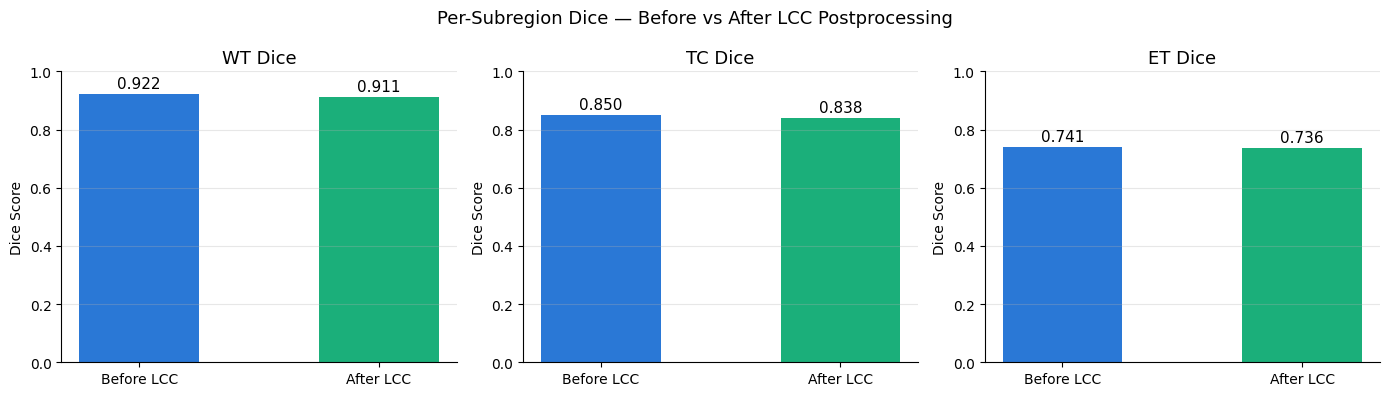

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

subregions = ["WT", "TC", "ET"]
before_cols = ["wt_before", "tc_before", "et_before"]
after_cols  = ["wt_after",  "tc_after",  "et_after"]
colors = ["#2a78d6", "#1baf7a"]

for ax, sr, bc, ac in zip(axes, subregions, before_cols, after_cols):

    data   = [results_df[bc].mean(), results_df[ac].mean()]
    labels = ["Before LCC", "After LCC"]
    bars   = ax.bar(labels, data, color=colors, width=0.5)

    ax.set_title(f"{sr} Dice", fontsize=13, fontweight="normal")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Dice Score")
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, val in zip(bars, data):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=11
        )

plt.suptitle("Per-Subregion Dice — Before vs After LCC Postprocessing", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "subregion_dice.png", dpi=150)
plt.show()

### 7.4 Per-Patient Dice Distribution

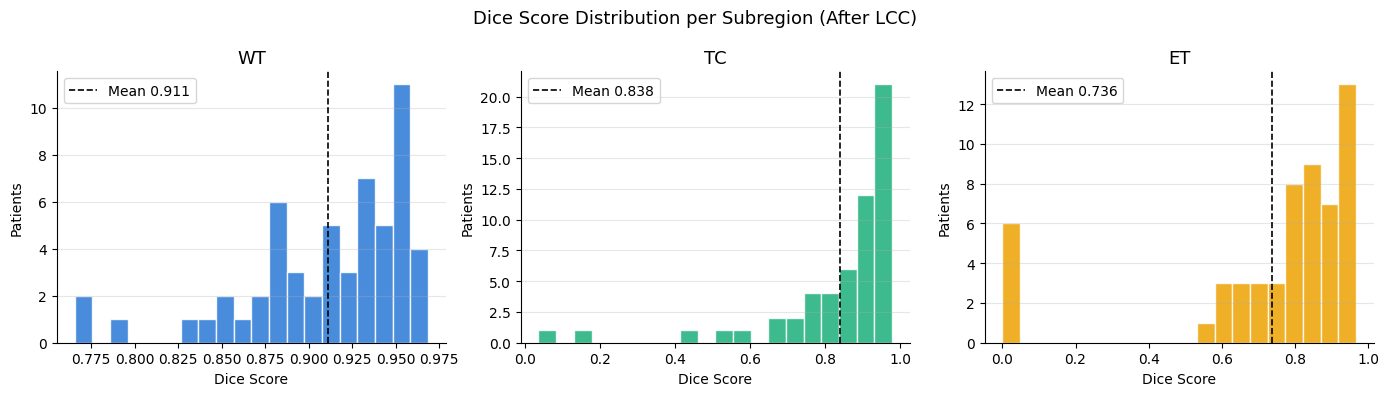

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

subregions = ["WT", "TC", "ET"]
after_cols = ["wt_after", "tc_after", "et_after"]
colors     = ["#2a78d6", "#1baf7a", "#eda100"]

for ax, sr, ac, color in zip(axes, subregions, after_cols, colors):
    ax.hist(results_df[ac], bins=20, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(results_df[ac].mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean {results_df[ac].mean():.3f}")
    ax.set_title(f"{sr}", fontsize=13)
    ax.set_xlabel("Dice Score")
    ax.set_ylabel("Patients")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Dice Score Distribution per Subregion (After LCC)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dice_distribution.png", dpi=150)
plt.show()

## 8. Prediction Visualization

### 8.1 Color Map

| Color | Label | Region |
|-------|-------|--------|
| Red | 1 | NCR/NET — Necrotic Core |
| Green | 2 | ED — Peritumoral Edema |
| Blue | 3 | ET — Enhancing Tumor |

In [16]:
LABEL_COLORS = {
    1: [1.0, 0.2, 0.2],   # red   — NCR
    2: [0.2, 0.9, 0.3],   # green — edema
    3: [0.2, 0.5, 1.0],   # blue  — ET
}

def overlay_mask(image_slice, mask_slice, alpha=0.45):
    """
    Overlay a colored segmentation mask on a grayscale MRI slice.

    Parameters
    ----------
    image_slice : np.ndarray  (H, W)  float, any range
    mask_slice  : np.ndarray  (H, W)  integer class indices

    Returns
    -------
    np.ndarray  (H, W, 3)  RGB float in [0, 1]
    """
    # Normalize image to [0, 1]
    img = image_slice.copy().astype(float)
    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())

    rgb = np.stack([img, img, img], axis=-1)

    for label_val, color in LABEL_COLORS.items():
        mask = mask_slice == label_val
        for c in range(3):
            rgb[:, :, c] = np.where(mask, rgb[:, :, c] * (1 - alpha) + color[c] * alpha, rgb[:, :, c])

    return np.clip(rgb, 0, 1)

### 8.2 Visualize Best, Median, and Worst Patients

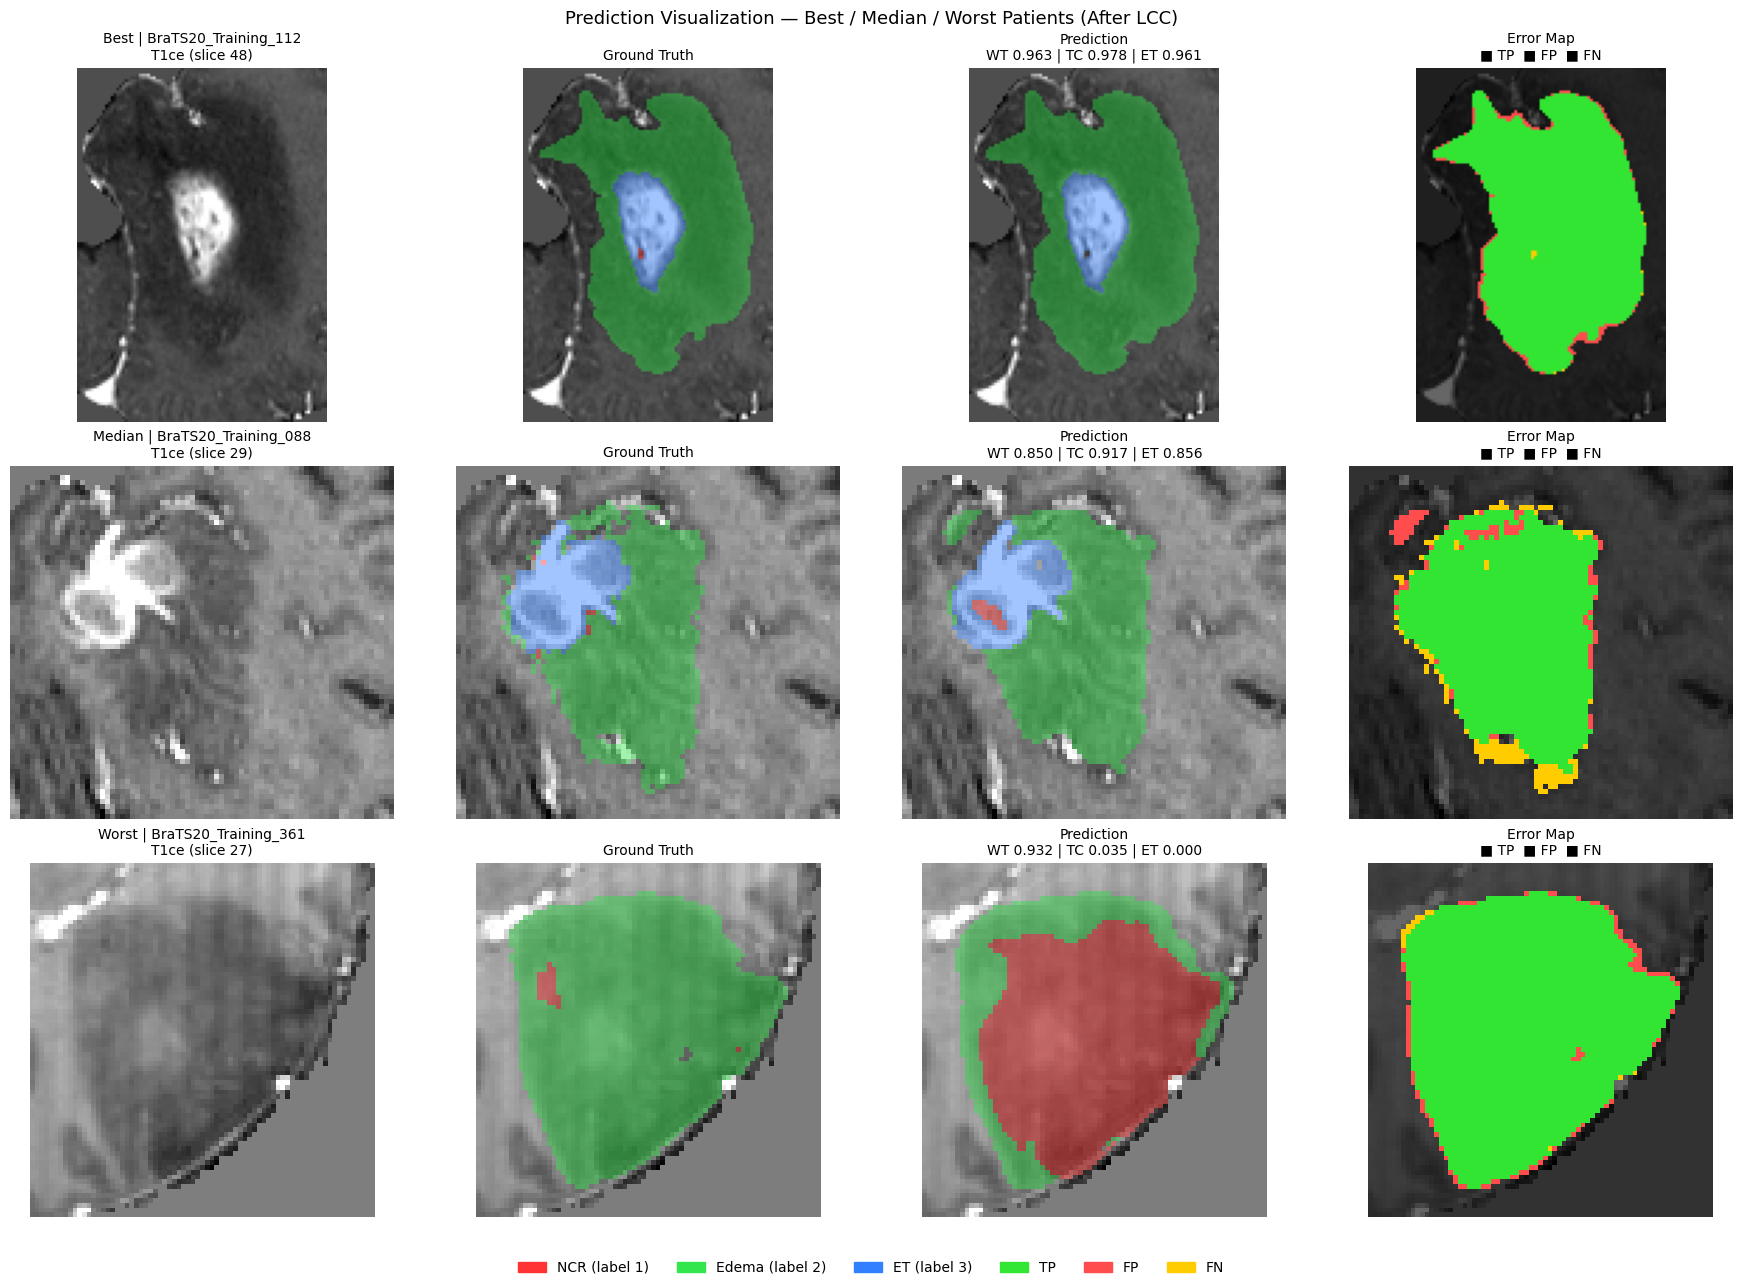

In [17]:
# Sort by mean Dice after LCC
sorted_records = sorted(records, key=lambda r: r["mean_after"])

worst  = sorted_records[0]
median = sorted_records[len(sorted_records) // 2]
best   = sorted_records[-1]

selected = [
    ("Best",   best),
    ("Median", median),
    ("Worst",  worst),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for row_idx, (label_str, rec) in enumerate(selected):

    image  = rec["_image"]    # (4, D, H, W)  — FLAIR=0, T1=1, T1ce=2, T2=3
    pred   = rec["_pred_lcc"] # (D, H, W)
    gt     = rec["_label"]    # (D, H, W)

    # Find axial slice with most tumor voxels
    tumor_per_slice = (gt > 0).sum(axis=(1, 2))
    best_slice = int(tumor_per_slice.argmax())

    t1ce_slice = image[2, best_slice]   # T1ce — best for tumor contrast
    pred_slice = pred[best_slice]
    gt_slice   = gt[best_slice]

    mean_dice  = rec["mean_after"]
    patient_id = rec["patient_id"]

    # Col 0: T1ce raw
    axes[row_idx, 0].imshow(t1ce_slice, cmap="gray")
    axes[row_idx, 0].set_title(f"{label_str} | {patient_id}\nT1ce (slice {best_slice})", fontsize=10)
    axes[row_idx, 0].axis("off")

    # Col 1: Ground truth overlay
    gt_overlay = overlay_mask(t1ce_slice, gt_slice)
    axes[row_idx, 1].imshow(gt_overlay)
    axes[row_idx, 1].set_title("Ground Truth", fontsize=10)
    axes[row_idx, 1].axis("off")

    # Col 2: Prediction overlay
    pred_overlay = overlay_mask(t1ce_slice, pred_slice)
    axes[row_idx, 2].imshow(pred_overlay)
    axes[row_idx, 2].set_title(
        f"Prediction\nWT {rec['wt_after']:.3f} | TC {rec['tc_after']:.3f} | ET {rec['et_after']:.3f}",
        fontsize=10
    )
    axes[row_idx, 2].axis("off")

    # Col 3: Error map
    error = np.zeros((*pred_slice.shape, 3))
    tp = (pred_slice > 0) & (gt_slice > 0)
    fp = (pred_slice > 0) & (gt_slice == 0)
    fn = (pred_slice == 0) & (gt_slice > 0)

    error[tp] = [0.2, 0.9, 0.2]   # green = correct
    error[fp] = [1.0, 0.3, 0.3]   # red   = false positive
    error[fn] = [1.0, 0.8, 0.0]   # yellow = false negative

    # Background: grayscale
    bg = np.stack([t1ce_slice]*3, axis=-1)
    bg = (bg - bg.min()) / (bg.max() - bg.min() + 1e-8)
    mask_any = ((pred_slice > 0) | (gt_slice > 0))
    for c in range(3):
        error[:, :, c] = np.where(mask_any[:, :], error[:, :, c], bg[:, :, c] * 0.4)

    axes[row_idx, 3].imshow(np.clip(error, 0, 1))
    axes[row_idx, 3].set_title("Error Map\n■ TP  ■ FP  ■ FN", fontsize=10)
    axes[row_idx, 3].axis("off")

# Legend
patches = [
    mpatches.Patch(color=[1.0, 0.2, 0.2], label="NCR (label 1)"),
    mpatches.Patch(color=[0.2, 0.9, 0.3], label="Edema (label 2)"),
    mpatches.Patch(color=[0.2, 0.5, 1.0], label="ET (label 3)"),
    mpatches.Patch(color=[0.2, 0.9, 0.2], label="TP"),
    mpatches.Patch(color=[1.0, 0.3, 0.3], label="FP"),
    mpatches.Patch(color=[1.0, 0.8, 0.0], label="FN"),
]
fig.legend(handles=patches, loc="lower center", ncol=6, fontsize=10, frameon=False)

plt.suptitle("Prediction Visualization — Best / Median / Worst Patients (After LCC)", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(FIGURE_DIR / "predictions_visualization.png", dpi=150)
plt.show()

### 8.3 Visualize Worst ET Patients

ET is the hardest subregion — inspect the patients where the model struggles most.

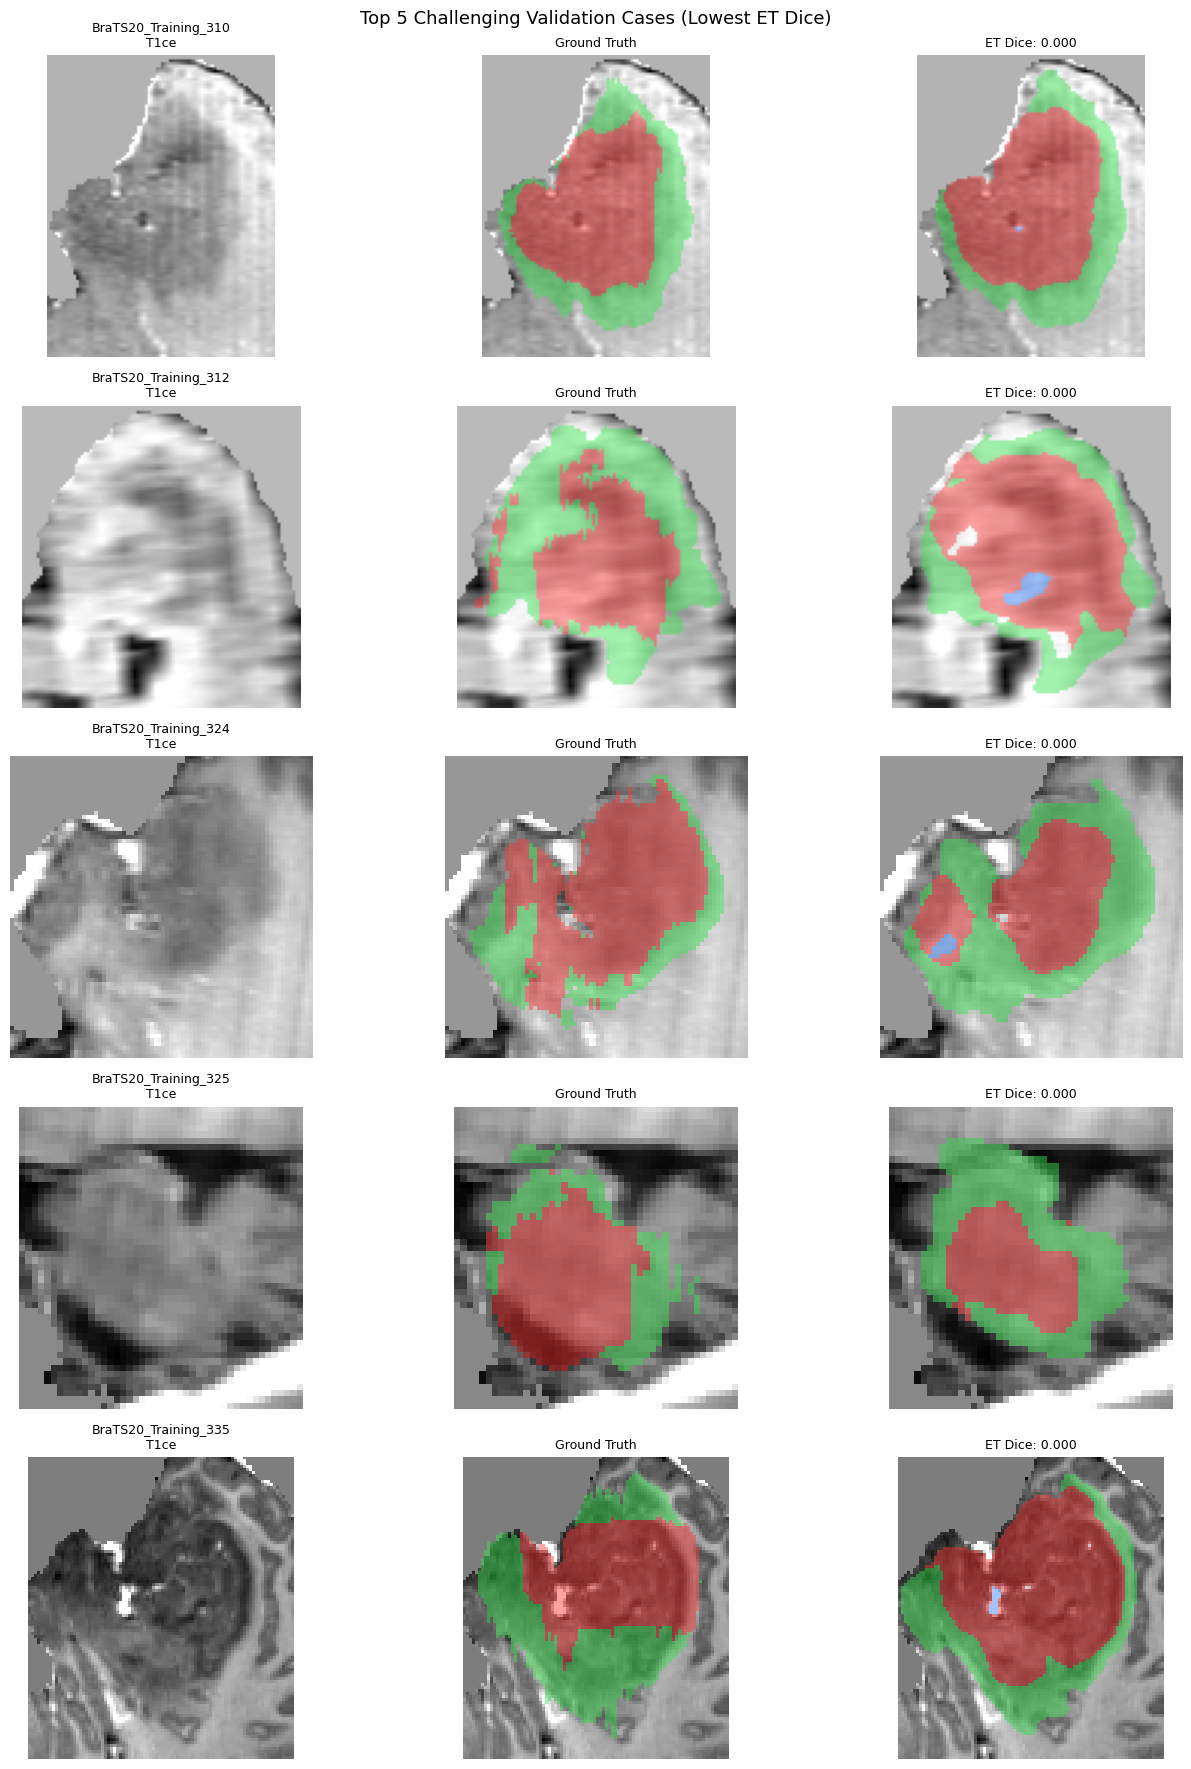

In [18]:
worst_et = sorted(records, key=lambda r: r["et_after"])[:5]

fig, axes = plt.subplots(5, 3, figsize=(14, 18))

for row_idx, rec in enumerate(worst_et):

    image = rec["_image"]
    pred  = rec["_pred_lcc"]
    gt    = rec["_label"]

    tumor_per_slice = (gt > 0).sum(axis=(1, 2))
    best_slice = int(tumor_per_slice.argmax())

    t1ce_slice = image[2, best_slice]
    pred_slice = pred[best_slice]
    gt_slice   = gt[best_slice]

    axes[row_idx, 0].imshow(t1ce_slice, cmap="gray")
    axes[row_idx, 0].set_title(f"{rec['patient_id']}\nT1ce", fontsize=9)
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(overlay_mask(t1ce_slice, gt_slice))
    axes[row_idx, 1].set_title("Ground Truth", fontsize=9)
    axes[row_idx, 1].axis("off")

    axes[row_idx, 2].imshow(overlay_mask(t1ce_slice, pred_slice))
    axes[row_idx, 2].set_title(
        f"ET Dice: {rec['et_after']:.3f}", fontsize=9
    )
    axes[row_idx, 2].axis("off")

plt.suptitle("Top 5 Challenging Validation Cases (Lowest ET Dice)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "worst_et_patients.png", dpi=150)
plt.show()

## 9. Summary

In [19]:
print("=" * 55)
print("Evaluation Summary — SegResNet BraTS2020")
print("=" * 55)
print()
print(f"Validation patients : {len(records)}")
print()
print(f"{'Subregion':<12} {'Before LCC':>12} {'After LCC':>12} {'Delta':>8}")
print("-" * 46)

for _, row in summary.iterrows():
    delta_str = f"+{row['Delta']:.4f}" if row["Delta"] >= 0 else f"{row['Delta']:.4f}"
    print(f"{row['Subregion']:<12} {row['Before LCC']:>12.4f} {row['After LCC']:>12.4f} {delta_str:>8}")

print()
print("Artifacts saved:")
print(f"  {RESULT_DIR / 'evaluation_results.csv'}")
print(f"  {FIGURE_DIR / 'subregion_dice.png'}")
print(f"  {FIGURE_DIR / 'dice_distribution.png'}")
print(f"  {FIGURE_DIR / 'predictions_visualization.png'}")
print(f"  {FIGURE_DIR / 'worst_et_patients.png'}")

Evaluation Summary — SegResNet BraTS2020

Validation patients : 56

Subregion      Before LCC    After LCC    Delta
----------------------------------------------
WT                 0.9225       0.9112  -0.0113
TC                 0.8502       0.8383  -0.0119
ET                 0.7410       0.7364  -0.0046
Mean               0.8379       0.8287  -0.0093

Artifacts saved:
  /kaggle/working/reports/results/evaluation_results.csv
  /kaggle/working/reports/figures/subregion_dice.png
  /kaggle/working/reports/figures/dice_distribution.png
  /kaggle/working/reports/figures/predictions_visualization.png
  /kaggle/working/reports/figures/worst_et_patients.png
